# Firing-Rate PCA: Temporal vs Spatial Encoding by Environment

**Hypothesis**: in **fam2** recordings, the first principal components of the firing-rate matrix correlate more strongly with time (suggesting temporal drift / non-stationarity) than in other environments (fam1, novel, fam1rev), where the dominant PCs encode angular position.

For every recording (≥ 30 neurons) we:
1. Fit **PCA directly on firing rates** (not tuning curves) and keep the first 3 PCs
2. Measure how much each PC correlates with **normalised time** (0 → 1) — linear Pearson |r|
3. Measure how much each PC encodes **angular position (φ)** — both linear |r| and sin/cos R²
4. Compare these metrics across **run types** (fam1, fam2, nov, fam1rev) and **genotype × age groups**

In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

from remapping.dataset import MiceDataset, Animals, GROUP_ORDER
from remapping.plotting import BehaviorColors, PlotStyle, get_figures_path
from remapping.metrics import safe_corrcoef, r_squared

mice = MiceDataset()
colors = BehaviorColors()
style = PlotStyle()
palette = mice.get_group_palette()


def annotate_violins(ax, data, x, y, order, width=0.15):
    """Overlay Q1/Q3 lines, median line, and mean diamond on violin plots."""
    for i, cat in enumerate(order):
        vals = data.loc[data[x] == cat, y].dropna()
        if len(vals) == 0:
            continue
        q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
        mean_val = vals.mean()
        ax.hlines([q1, q3], i - width, i + width, color="k", linewidth=0.8, zorder=3)
        ax.hlines(med, i - width, i + width, color="k", linewidth=1.5, zorder=3)
        ax.scatter(i, mean_val, marker="D", color="white", edgecolors="k",
                   s=14, linewidths=0.8, zorder=4)

In [2]:
# --- Parameters ---

# Processing pipeline
ONLY_MOVING = True
BINS_COMPRESS = 3
BINS_SMOOTHING = 3
BINS_PHI = 360
MIN_NEURONS = 30

# Embedding
N_COMPONENTS = 3

# Run-type mapping: fam1r2 (return to fam1) grouped with fam1
RUN_TYPE_MAP = {
    "fam1": "fam1",
    "fam2": "fam2",
    "nov": "nov",
    "fam1rev": "fam1rev",
    "fam1r2": "fam1",
}
RUN_TYPE_ORDER = ["fam1", "fam2", "nov", "fam1rev"]
RUN_TYPE_COLORS = {
    "fam1": "#e85d04",   # orange (familiar 1)
    "fam2": "#0a85ed",   # blue (familiar 2)
    "nov": "#99ca3c",    # green (novel)
    "fam1rev": "#d727fc", # purple (reversed)
}

# Figure output
fig_path = get_figures_path("1.embeddings", "03_fam2_correlates")

## 1 — Compute time and space correlations of firing-rate PCs

For each recording, fit PCA on the firing-rate matrix (T × N), then for each of the first 3 PCs:
- **Time correlation**: |Pearson r| between PC scores and normalised time (0 → 1)
- **Angular-position correlation**: |Pearson r| between PC scores and φ (linear)
- **Angular-position R²**: R² from regressing the PC onto sin(φ) and cos(φ) (captures circular structure)

In [3]:
records = []

for subject in Animals:
    info = mice.get_subject_info(subject)
    group = f"{info['genotype']}_{info['age']}"
    for fov in mice.get_available_fovs(subject):
        for session in mice.get_available_sessions(subject, fov):
            for run in mice.get_available_runs(subject, fov, session):
                # Load processed firing rates
                firing_rates, phi, time, (cell_ids, _), tc_raw, phi_bins = (
                    mice.load_firing_rates(
                        subject, fov, session, run,
                        only_moving=ONLY_MOVING,
                        bins_compress=BINS_COMPRESS,
                        bins_smoothing=BINS_SMOOTHING,
                        bins_phi=BINS_PHI,
                    )
                )
                n_neurons = firing_rates.shape[1]
                if n_neurons < MIN_NEURONS:
                    continue

                # Drop NaN phi time-bins
                valid = ~np.isnan(phi)
                if valid.sum() < 100:
                    continue
                fr = firing_rates[valid]
                phi_v = phi[valid]
                time_v = time[valid]

                # Normalise time to [0, 1]
                time_norm = (time_v - time_v.min()) / (time_v.max() - time_v.min())

                # PCA on firing rates
                pca = PCA(n_components=N_COMPONENTS)
                pc_scores = pca.fit_transform(fr)  # (T, 3)

                # Prepare sin/cos basis for circular regression
                phi_rad = np.deg2rad(phi_v)
                X_sincos = np.column_stack([np.sin(phi_rad), np.cos(phi_rad)])

                rec = {
                    "subject": subject.value, "fov": fov,
                    "session": session, "run": run,
                    "run_type": RUN_TYPE_MAP[run],
                    "group": group, "n_neurons": n_neurons,
                }

                # Per-PC metrics
                time_corrs = []
                phi_corrs = []
                phi_r2s = []
                for i in range(N_COMPONENTS):
                    pc = pc_scores[:, i]

                    # Time correlation (absolute value)
                    r_time = abs(safe_corrcoef(pc, time_norm))
                    time_corrs.append(r_time)
                    rec[f"time_corr_pc{i+1}"] = r_time

                    # Phi linear correlation (absolute value)
                    r_phi = abs(safe_corrcoef(pc, phi_v))
                    phi_corrs.append(r_phi)
                    rec[f"phi_corr_pc{i+1}"] = r_phi

                    # Phi sin/cos R²
                    beta, _, _, _ = np.linalg.lstsq(X_sincos, pc, rcond=None)
                    pc_pred = X_sincos @ beta
                    r2_phi = r_squared(pc, pc_pred)
                    phi_r2s.append(r2_phi)
                    rec[f"phi_r2_pc{i+1}"] = r2_phi

                # Combined (max across first 3 PCs)
                rec["max_time_corr"] = max(time_corrs)
                rec["max_phi_corr"] = max(phi_corrs)
                rec["max_phi_r2"] = max(phi_r2s)

                # Variance explained
                for i in range(N_COMPONENTS):
                    rec[f"var_pc{i+1}"] = pca.explained_variance_ratio_[i]
                rec["cumvar_3"] = pca.explained_variance_ratio_[:N_COMPONENTS].sum()

                records.append(rec)

df = pd.DataFrame(records)
print(f"Collected {len(df)} recordings (≥ {MIN_NEURONS} neurons)")
print(f"\nRun-type counts:\n{df['run_type'].value_counts().reindex(RUN_TYPE_ORDER)}")
print(f"\nGroup counts:\n{df['group'].value_counts().reindex(GROUP_ORDER)}")

Collected 321 recordings (≥ 30 neurons)

Run-type counts:
run_type
fam1       204
fam2        42
nov         41
fam1rev     34
Name: count, dtype: int64

Group counts:
group
WT_young       105
WT_old          32
5xFAD_young     71
5xFAD_old      113
Name: count, dtype: int64


## 2 — Time correlation by run type

Max |Pearson r| between any of the first 3 firing-rate PCs and normalised time, grouped by environment.
If fam2 PCs are more temporally driven, fam2 should show higher values than fam1 / nov / fam1rev.

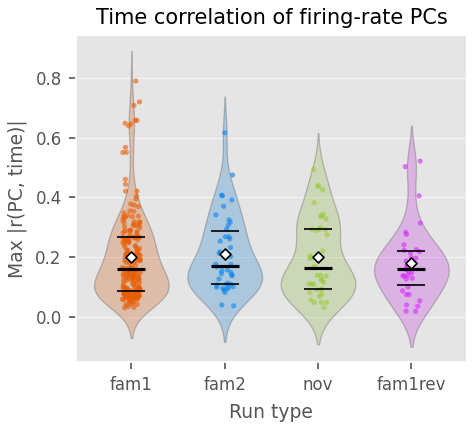

In [4]:
# --- Combined: max time correlation across PC1-3 ---
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.0))
sns.violinplot(
    data=df, x="run_type", y="max_time_corr", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    inner=None, alpha=0.3, legend=False, ax=ax,
)
sns.stripplot(
    data=df, x="run_type", y="max_time_corr", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
)
annotate_violins(ax, df, "run_type", "max_time_corr", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Max |r(PC, time)|")
ax.set_title("Time correlation of firing-rate PCs")
plt.tight_layout()
fig.savefig(fig_path / "time_corr_by_run_type.pdf")
plt.show()

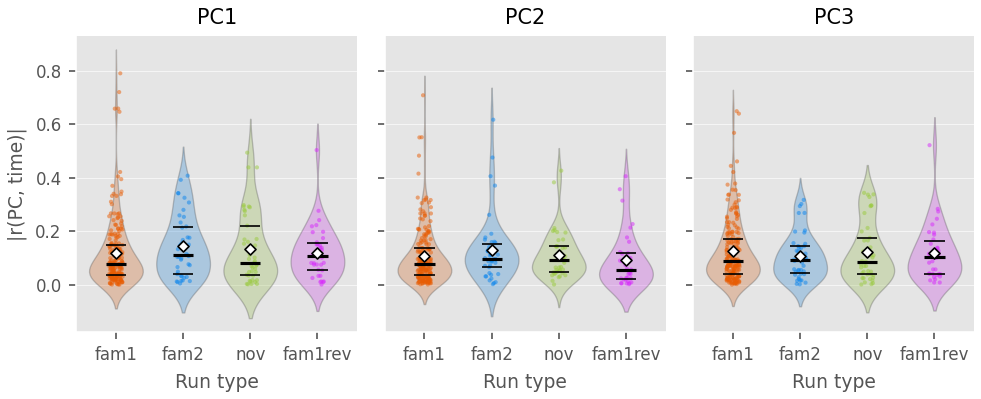

In [5]:
# --- Per-PC time correlation breakdown ---
fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 2.8), sharey=True)
for i, ax in enumerate(axes):
    col = f"time_corr_pc{i+1}"
    sns.violinplot(
        data=df, x="run_type", y=col, hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        inner=None, alpha=0.3, legend=False, ax=ax,
    )
    sns.stripplot(
        data=df, x="run_type", y=col, hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        size=2, alpha=0.5, jitter=True, legend=False, ax=ax,
    )
    annotate_violins(ax, df, "run_type", col, RUN_TYPE_ORDER)
    ax.set_title(f"PC{i+1}")
    ax.set_xlabel("Run type")
    if i == 0:
        ax.set_ylabel("|r(PC, time)|")
    else:
        ax.set_ylabel("")
plt.tight_layout()
fig.savefig(fig_path / "time_corr_per_pc.pdf")
plt.show()

## 3 — Angular-position encoding by run type

How much do the first 3 firing-rate PCs encode angular position (φ)?

- **Linear correlation**: |Pearson r(PC, φ)| — simple but ignores circular wrapping
- **Sin/cos R²**: variance explained by regressing PC onto sin(φ) and cos(φ) — captures the circular relationship properly

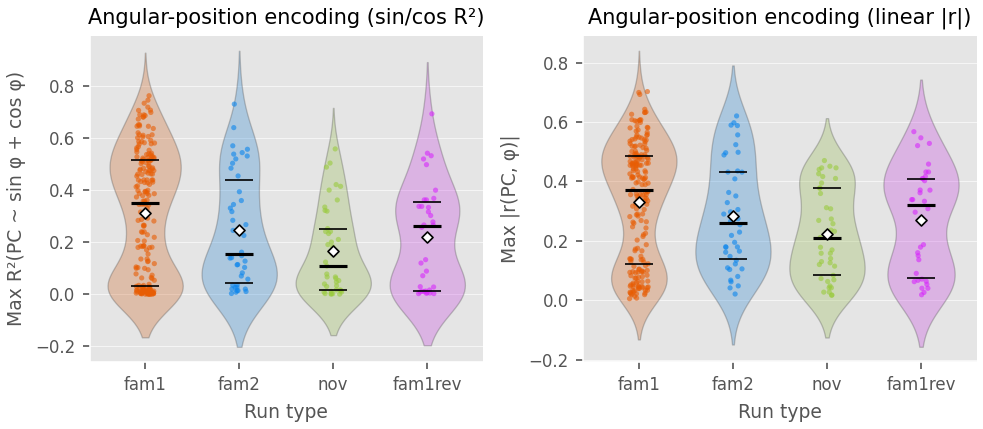

In [6]:
# --- Combined: max sin/cos R² across PC1-3 ---
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.0))

# Left: sin/cos R²
ax = axes[0]
sns.violinplot(
    data=df, x="run_type", y="max_phi_r2", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    inner=None, alpha=0.3, legend=False, ax=ax,
)
sns.stripplot(
    data=df, x="run_type", y="max_phi_r2", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
)
annotate_violins(ax, df, "run_type", "max_phi_r2", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Max R²(PC ~ sin φ + cos φ)")
ax.set_title("Angular-position encoding (sin/cos R²)")

# Right: linear correlation
ax = axes[1]
sns.violinplot(
    data=df, x="run_type", y="max_phi_corr", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    inner=None, alpha=0.3, legend=False, ax=ax,
)
sns.stripplot(
    data=df, x="run_type", y="max_phi_corr", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
)
annotate_violins(ax, df, "run_type", "max_phi_corr", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Max |r(PC, φ)|")
ax.set_title("Angular-position encoding (linear |r|)")

plt.tight_layout()
fig.savefig(fig_path / "phi_encoding_by_run_type.pdf")

plt.show()

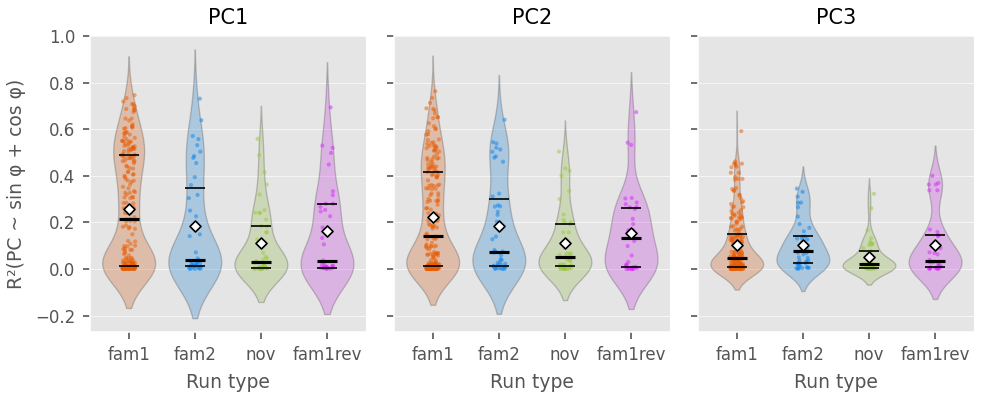

In [7]:
# --- Per-PC sin/cos R² breakdown ---
fig, axes = plt.subplots(1, 3, figsize=(PlotStyle.FULL_WIDTH, 2.8), sharey=True)
for i, ax in enumerate(axes):
    col = f"phi_r2_pc{i+1}"
    sns.violinplot(
        data=df, x="run_type", y=col, hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        inner=None, alpha=0.3, legend=False, ax=ax,
    )
    sns.stripplot(
        data=df, x="run_type", y=col, hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        size=2, alpha=0.5, jitter=True, legend=False, ax=ax,
    )
    annotate_violins(ax, df, "run_type", col, RUN_TYPE_ORDER)
    ax.set_title(f"PC{i+1}")
    ax.set_xlabel("Run type")
    if i == 0:
        ax.set_ylabel("R²(PC ~ sin φ + cos φ)")
    else:
        ax.set_ylabel("")
plt.tight_layout()
fig.savefig(fig_path / "phi_r2_per_pc.pdf")
plt.show()

## 4 — Time vs space: scatter

Each point is one recording. If fam2 PCs are more temporally driven, fam2 points should cluster in the upper-left region (high time correlation, low spatial encoding).

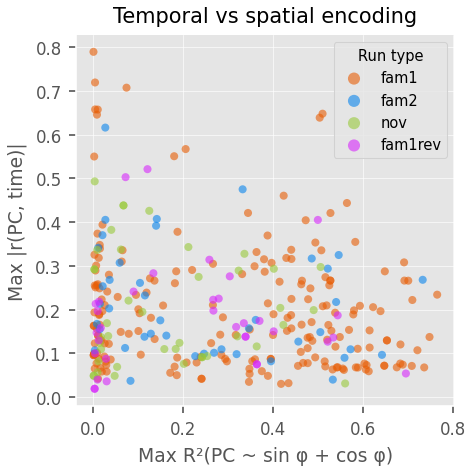

In [8]:
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.3))
for rt in RUN_TYPE_ORDER:
    mask = df["run_type"] == rt
    ax.scatter(
        df.loc[mask, "max_phi_r2"],
        df.loc[mask, "max_time_corr"],
        c=RUN_TYPE_COLORS[rt], label=rt, s=15, alpha=0.6, edgecolors="none",
    )
ax.set_xlabel("Max R²(PC ~ sin φ + cos φ)")
ax.set_ylabel("Max |r(PC, time)|")
ax.set_title("Temporal vs spatial encoding")
ax.legend(title="Run type", fontsize=7, title_fontsize=7, markerscale=1.5)
plt.tight_layout()
fig.savefig(fig_path / "time_vs_space_scatter.pdf")
plt.show()

## 5 — Variance explained by run type

Cumulative variance in the first 3 PCs of the firing-rate PCA, by environment.
Contextualises whether the time-correlated PCs in fam2 also carry more or less total variance.

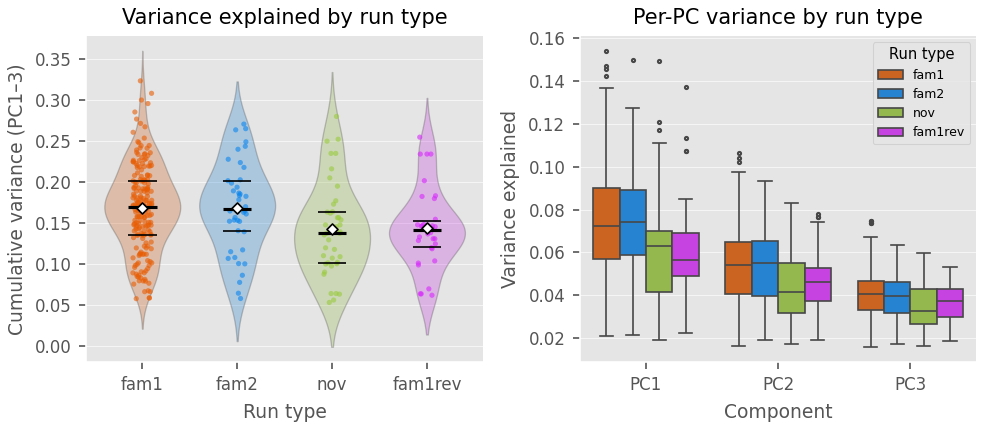

In [9]:
# --- Cumulative variance in first 3 PCs ---
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 3.0))

# Left: cumulative variance by run type
ax = axes[0]
sns.violinplot(
    data=df, x="run_type", y="cumvar_3", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    inner=None, alpha=0.3, legend=False, ax=ax,
)
sns.stripplot(
    data=df, x="run_type", y="cumvar_3", hue="run_type",
    order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
)
annotate_violins(ax, df, "run_type", "cumvar_3", RUN_TYPE_ORDER)
ax.set_xlabel("Run type")
ax.set_ylabel("Cumulative variance (PC1–3)")
ax.set_title("Variance explained by run type")

# Right: individual PC variance
df_var_melt = df.melt(
    id_vars=["run_type"],
    value_vars=["var_pc1", "var_pc2", "var_pc3"],
    var_name="PC", value_name="Variance explained",
)
df_var_melt["PC"] = df_var_melt["PC"].str.replace("var_pc", "PC")
ax = axes[1]
sns.boxplot(
    data=df_var_melt, x="PC", y="Variance explained", hue="run_type",
    hue_order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
    fliersize=1.5, linewidth=0.8, ax=ax,
)
ax.set_xlabel("Component")
ax.set_ylabel("Variance explained")
ax.set_title("Per-PC variance by run type")
ax.legend(title="Run type", fontsize=6, title_fontsize=7, loc="upper right")

plt.tight_layout()
fig.savefig(fig_path / "variance_by_run_type.pdf")
plt.show()

## 6 — Breakdown by genotype × age group

Is the fam2 temporal bias uniform across all groups, or driven by a specific genotype/age?

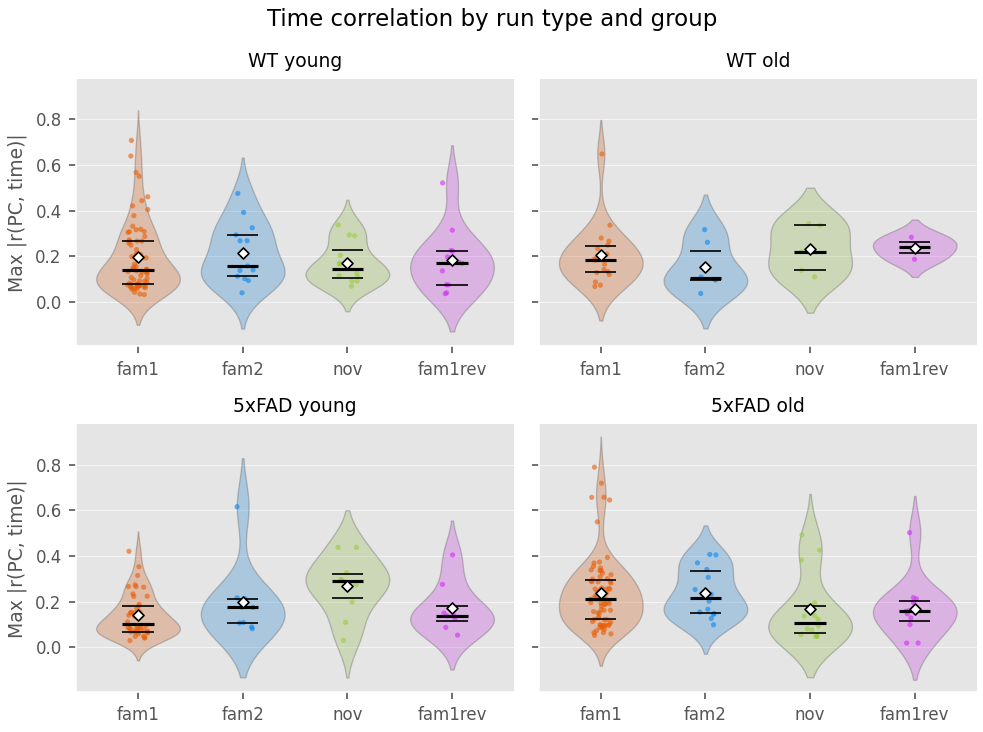

In [10]:
# --- Time correlation by run type, faceted by group ---
fig, axes = plt.subplots(2, 2, figsize=(PlotStyle.FULL_WIDTH, 5.0), sharey=True)
for idx, group in enumerate(GROUP_ORDER):
    ax = axes.flat[idx]
    sub = df[df["group"] == group]
    sns.violinplot(
        data=sub, x="run_type", y="max_time_corr", hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        inner=None, alpha=0.3, legend=False, ax=ax,
    )
    sns.stripplot(
        data=sub, x="run_type", y="max_time_corr", hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
    )
    annotate_violins(ax, sub, "run_type", "max_time_corr", RUN_TYPE_ORDER)
    ax.set_title(group.replace("_", " "), fontsize=9)
    ax.set_xlabel("")
    if idx % 2 == 0:
        ax.set_ylabel("Max |r(PC, time)|")
    else:
        ax.set_ylabel("")
fig.suptitle("Time correlation by run type and group", fontsize=11)
plt.tight_layout()
fig.savefig(fig_path / "time_corr_by_group.pdf")
plt.show()

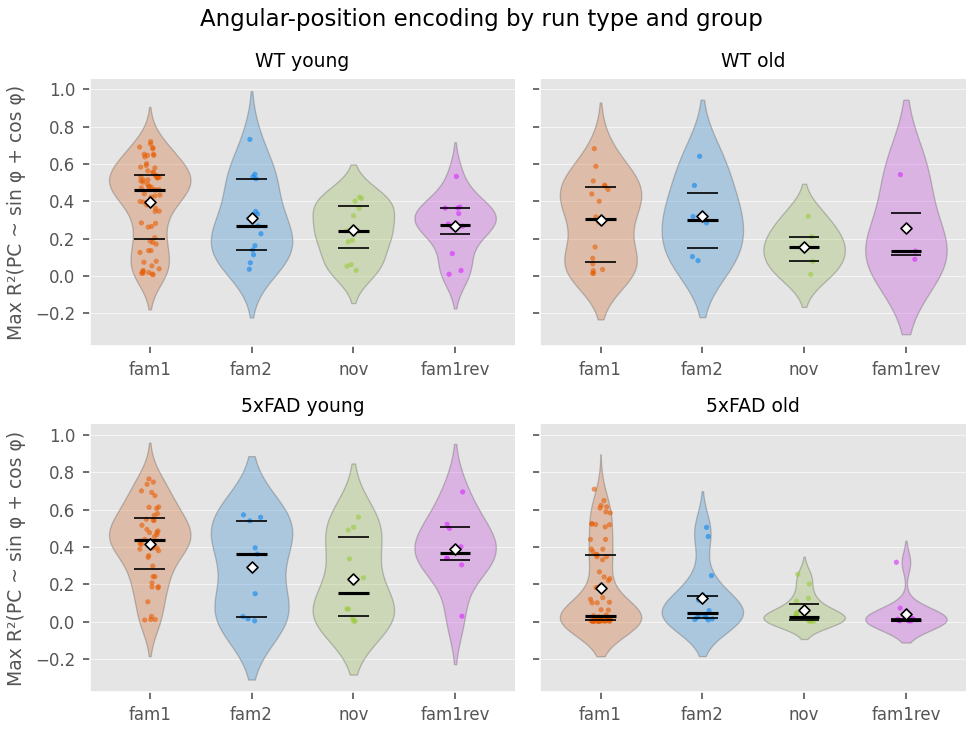

In [11]:
# --- Phi R² by run type, faceted by group ---
fig, axes = plt.subplots(2, 2, figsize=(PlotStyle.FULL_WIDTH, 5.0), sharey=True)
for idx, group in enumerate(GROUP_ORDER):
    ax = axes.flat[idx]
    sub = df[df["group"] == group]
    sns.violinplot(
        data=sub, x="run_type", y="max_phi_r2", hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        inner=None, alpha=0.3, legend=False, ax=ax,
    )
    sns.stripplot(
        data=sub, x="run_type", y="max_phi_r2", hue="run_type",
        order=RUN_TYPE_ORDER, palette=RUN_TYPE_COLORS,
        size=2.5, alpha=0.6, jitter=True, legend=False, ax=ax,
    )
    annotate_violins(ax, sub, "run_type", "max_phi_r2", RUN_TYPE_ORDER)
    ax.set_title(group.replace("_", " "), fontsize=9)
    ax.set_xlabel("")
    if idx % 2 == 0:
        ax.set_ylabel("Max R²(PC ~ sin φ + cos φ)")
    else:
        ax.set_ylabel("")
fig.suptitle("Angular-position encoding by run type and group", fontsize=11)
plt.tight_layout()
fig.savefig(fig_path / "phi_r2_by_group.pdf")
plt.show()

## 7 — Example traces: PC1 vs time

One representative recording per run type — the one closest to the median `max_time_corr` for that run type.
PC1 scores plotted against normalised time, colour-coded by angular position.
Visually illustrates what "time-correlated PC" looks like for fam2 versus fam1 / nov / fam1rev.

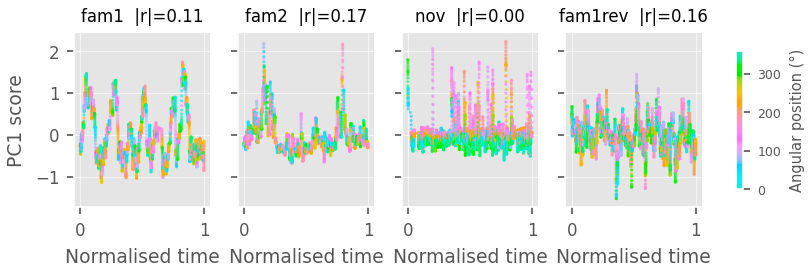

In [12]:
# Pick one example per run type (closest to median max_time_corr)
examples = {}
for rt in RUN_TYPE_ORDER:
    sub = df[df["run_type"] == rt]
    med = sub["max_time_corr"].median()
    best_idx = (sub["max_time_corr"] - med).abs().idxmin()
    examples[rt] = sub.loc[best_idx]

phi_cmap = colors.angular_position
norm = plt.Normalize(0, 360)

fig, axes = plt.subplots(1, 4, figsize=(PlotStyle.FULL_WIDTH, 1.5), sharey=True)
for idx, rt in enumerate(RUN_TYPE_ORDER):
    ax = axes[idx]
    row = examples[rt]

    # Reload data for this recording
    subject = Animals(row["subject"])
    firing_rates, phi, time, _, _, _ = mice.load_firing_rates(
        subject, row["fov"], row["session"], row["run"],
        only_moving=ONLY_MOVING, bins_compress=BINS_COMPRESS,
        bins_smoothing=BINS_SMOOTHING, bins_phi=BINS_PHI,
    )
    valid = ~np.isnan(phi)
    fr = firing_rates[valid]
    phi_v = phi[valid]
    time_v = time[valid]
    time_norm = (time_v - time_v.min()) / (time_v.max() - time_v.min())

    pca = PCA(n_components=N_COMPONENTS)
    pc_scores = pca.fit_transform(fr)

    ax.scatter(time_norm, pc_scores[:, 0], c=phi_v, cmap=phi_cmap,
               norm=norm, s=1, alpha=0.5, rasterized=True)
    r_val = abs(safe_corrcoef(pc_scores[:, 0], time_norm))
    ax.set_title(f"{rt}  |r|={r_val:.2f}", fontsize=8)
    ax.set_xlabel("Normalised time")
    if idx == 0:
        ax.set_ylabel("PC1 score")

sm = plt.cm.ScalarMappable(cmap=phi_cmap, norm=norm)
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Angular position (°)", fontsize=7)
cbar.ax.tick_params(labelsize=6)

fig.subplots_adjust(right=0.75)
fig.savefig(fig_path / "example_pc1_vs_time.pdf")
plt.show()

## 8 — Summary statistics

Median [Q1, Q3] of key metrics per run type.

In [13]:
metrics = ["max_time_corr", "max_phi_r2", "max_phi_corr", "cumvar_3"]
summary_rows = []
for rt in RUN_TYPE_ORDER:
    sub = df[df["run_type"] == rt]
    row = {"run_type": rt, "n": len(sub)}
    for m in metrics:
        q1, med, q3 = sub[m].quantile([0.25, 0.5, 0.75])
        row[m] = f"{med:.3f} [{q1:.3f}, {q3:.3f}]"
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("run_type")
summary.columns = ["n", "Max |r(PC,time)|", "Max R²(PC~φ)", "Max |r(PC,φ)|", "Cum. var PC1–3"]
summary

,n,"Max |r(PC,time)|",Max R²(PC~φ),"Max |r(PC,φ)|",Cum. var PC1–3
run_type,,,,,
fam1,204,"0.160 [0.087, 0.266]","0.350 [0.031, 0.516]","0.370 [0.121, 0.486]","0.170 [0.136, 0.201]"
fam2,42,"0.171 [0.109, 0.287]","0.156 [0.042, 0.440]","0.260 [0.138, 0.432]","0.167 [0.140, 0.201]"
nov,41,"0.165 [0.093, 0.293]","0.109 [0.017, 0.253]","0.211 [0.084, 0.378]","0.137 [0.101, 0.164]"
fam1rev,34,"0.159 [0.106, 0.221]","0.262 [0.014, 0.357]","0.321 [0.076, 0.410]","0.141 [0.121, 0.153]"
